In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import scipy as sp
import cartopy.crs as ccrs
import cartopy.feature as cf
import cartopy.io.shapereader as shpreader
import shapely.geometry as sgeom
from shapely.ops import unary_union
from shapely.prepared import prep
from typing import Union

import numpy as np
import xarray as xr
import copy

In [2]:
olat = [x for x in range (0,100,10)]
olon = [x for x in range (0,100,10)]

odata = np.asarray(np.random.random((10,10)))+1
odata = xr.DataArray(odata, dims=['lon','lat'],coords={'lon':olon, 'lat':olat})

odata.loc[20,30] = np.nan

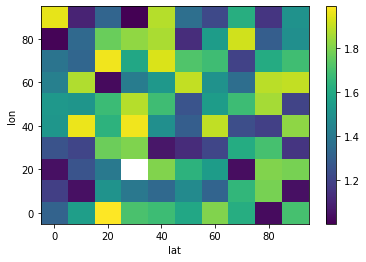

In [3]:
odata.plot()

In [4]:
ilat = [x for x in range (0,91)]
ilon = [x for x in range (0,91)]

idata = xr.DataArray(np.nan, dims=['lon','lat'],coords={'lon':ilon, 'lat':ilat})

In [5]:
def findsurrounding1d(array, value, indices = True, values = True):
    returnflag = False
    i = -1
    for x in array:
        i += 1
        if i >= len(array)-1:
            break
        if array[i] <= value and array[i+1] >=value:
            returnflag = True
        if array[i] >= value and array[i+1] <=value:
            returnflag = True
        if returnflag:
            returnlist = [True]
            if indices:
                returnlist.append(i)
                returnlist.append(i+1)
            if values:
                returnlist.append(array[i])
                returnlist.append(array[i+1])
            return returnlist
    returnlist = [False]
    if indices:
        returnlist.append(None)
        returnlist.append(None)
    if values:
        returnlist.append(None)
        returnlist.append(None)
    return returnlist
        

def invdist(odata: xr.DataArray, idata:xr.DataArray):
    # iterate through the interpolation points
    iloni = -1
    for ilon in idata.coords['lon'].data:
        iloni += 1
        found, lonlowind, lonhighind, lonlowval, lonhighval =  findsurrounding1d(odata.coords['lat'].data, ilon)
        if not found:
                continue
        ilati = -1
        for ilat in idata.coords['lat'].data:
            ilati += 1
            found, latlowind, lathighind, latlowval, lathighval =  findsurrounding1d(odata.coords['lat'].data, ilat)
            #if latlowind is None or lathighind is None or latlowval is None or lathighval is None or ilon is None or ilat is None:
            if not found:
                continue
            #determine total linear distances
            dist1 = np.linalg.norm(np.array([ilon-lonlowval, ilat-latlowval]))
            dist2 = np.linalg.norm(np.array([ilon-lonhighval, ilat-latlowval]))
            dist3 = np.linalg.norm(np.array([ilon-lonlowval, ilat-lathighval]))
            dist4 = np.linalg.norm(np.array([ilon-lonhighval, ilat-lathighval]))
            distsum = dist1 + dist2 + dist3 + dist4
            data1 = odata.data[lonlowind,latlowind]
            data2 = odata.data[lonhighind,latlowind]
            data3 = odata.data[lonlowind,lathighind]
            data4 = odata.data[lonhighind,lathighind]
            
            idata.loc[ilon,ilat] = distsum

                    

            

    
            


In [6]:
invdist(odata,idata)

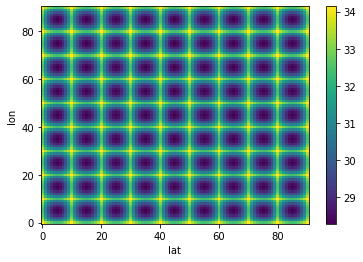

In [7]:
idata.plot()

In [16]:
idata = idata.chunk(2)
odata = odata.chunk(3)
wdata = odata.pad({'lon':(1,1),'lat':(0,0)},mode='wrap')
rdata = odata.interp(idata.coords,method='linear')

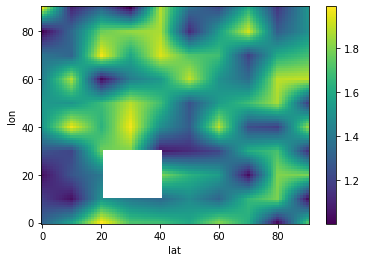

In [17]:
rdata.plot()

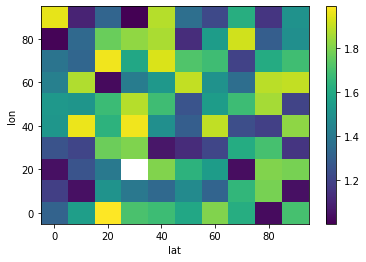

In [10]:
odata.plot()

In [11]:
odata.data[3,4]

1.0611937609892745

In [12]:
odata.loc[30,40]

<xarray.DataArray ()>
array(1.06119376)
Coordinates:
    lon      int64 30
    lat      int64 40

In [13]:
type(odata.name)

NoneType

In [14]:
def store_xarray_as_netcdf(data:xr.Dataset, variable_name:str = 'variable')-> None:
    sdata = copy.deepcopy(data)
    sdata = sdata.rename(variable_name)
    sdata.to_netcdf(str(variable_name + '.nc4'))

In [15]:
store_xarray_netcdf(odata, 'random_values')

NameError: name 'store_xarray_netcdf' is not defined

In [ ]:
wdata = xr.load_dataset('random_values.nc4')

In [ ]:
def read_xarray_from_netcdf(file_name:str)->xr.Dataset:
    if file_name[-4:] != '.nc4':
        file_name = str(file_name + '.nc4')
    return xr.load_dataset(file_name)

In [ ]:
wdata = read_xarray_from_netcdf('random_values')

In [ ]:
wdata

In [ ]:
testsliceone = np.ones((100,1))
testslicetwo = np.ones((100,1))
for loc, val in enumerate(testsliceone):
    if np.random.random()>0.9:
        testsliceone[loc] = np.nan
    if np.random.random()>0.9:
        testslicetwo[loc] = np.nan
    

In [ ]:
def mean_nan(array1, array2, axis=0):
    for loc, vals1, vals2 in enumerate(zip(array1,array2)):
        